<a href="https://colab.research.google.com/github/wilszon/Clase-Inteligencia-Artificial/blob/main/Fundamento_Cuaderno_9A_Cross_Validation_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red"> Validación Cruzada en Machine Learning
---
Este notebook cubre los conceptos fundamentales de **Cross Validation** (validación cruzada), incluyendo métodos aplicados a datos comunes y series temporales. También se incluyen ejemplos prácticos con scikit-learn.


## 📚 Índice
1. [Introducción a la Validación Cruzada](#1)
2. [Ejemplo de Validación Cruzada con KFold](#2)
3. [Cálculo de Métricas con Validación Cruzada](#3)
4. [Evaluación con `cross_validate`: Múltiples Métricas y Resultados Avanzados](#4)
5. [Obtención de Predicciones con `cross_val_predict](#5)
6. [Grid Search con Validación Cruzada](#6)
7. [Diferencia entre `KFold` y `StratifiedKFold](#7)


## 1. Introducción a la Validación Cruzada <a name='1'></a>


La validación cruzada es una técnica para evaluar el rendimiento de un modelo dividiendo los datos en partes (o *folds*) para entrenamiento y prueba de forma iterativa.

# ¿Por qué usar Validación Cruzada?

Al entrenar modelos de machine learning, es común dividir los datos disponibles en tres conjuntos: entrenamiento, validación y prueba. Sin embargo, al hacer esto, reducimos drásticamente la cantidad de muestras que se pueden usar para aprender el modelo, y los resultados pueden depender de una elección aleatoria particular para el par de conjuntos (entrenamiento, validación).

Una solución a este problema es un procedimiento denominado **validación cruzada (Cross Validation, CV)**. Un conjunto de prueba debe conservarse para la evaluación final, pero el conjunto de validación ya no es necesario al realizar CV.

En el enfoque básico, denominado **CV de k pliegues (k-fold cross validation)**, el conjunto de entrenamiento se divide en *k* subconjuntos (pliegues). Se sigue el siguiente procedimiento para cada uno de los *k* pliegues:

1. Se entrena un modelo utilizando *k-1* pliegues como datos de entrenamiento.
2. El modelo resultante se valida en el pliegue restante (utilizado como conjunto de prueba) para calcular una métrica de rendimiento (como la precisión).

La medida de rendimiento reportada por la validación cruzada de *k* pliegues es el promedio de los valores obtenidos en cada iteración.


![imagen](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

Este enfoque puede ser computacionalmente costoso, pero no desperdicia demasiados datos, lo cual constituye una gran ventaja en problemas con pocas muestras, como en tareas de inferencia inversa.


**¿Por qué usarla?**
- Evita overfitting (sobreajuste)
- Estima de forma más realista la capacidad de generalización del modelo


##  cross_val_predict / cross_val_score
Estas funciones sirven para evaluar el rendimiento del modelo, no para entrenar un modelo final.

* Lo que SÍ obtienes con cross-validation:
Métricas de rendimiento realistas (como accuracy, precision, etc.) sin overfitting.

Una idea clara de cómo se comportaría el modelo con datos nunca vistos.
* Lo que NO obtienes:
Un modelo entrenado que puedas guardar y usar para predecir luego.

Un "modelo final" usable para producción.

Por lo tanto debemos recordar cuáles son las métricas de scoring usadas para calidad del modelo.
![imagen](https://miro.medium.com/v2/resize:fit:507/1*i4D7Bb5SKjgaoFPxTC6pLA.png)



###  `KFold` y `StratifiedKFold` <a name='8'></a>

Ambos son técnicas de validación cruzada utilizadas para dividir un conjunto de datos en varios pliegues (`folds`) para entrenar y evaluar modelos de manera más robusta. La diferencia principal está en **cómo se distribuyen las clases (etiquetas) entre los pliegues**:


#### `KFold`
- Divide los datos **en partes iguales**, sin tener en cuenta la proporción de clases.
- Puede generar desequilibrios en los conjuntos de entrenamiento/prueba si los datos están desbalanceados.
- Útil para regresión o clasificación cuando las clases están bien representadas.



#### `StratifiedKFold`
- Intenta mantener la **misma proporción de clases en cada pliegue** que en el conjunto original.
- Ideal para clasificación, especialmente cuando hay clases desbalanceadas.
- Evita que un pliegue quede con muy pocas muestras de alguna clase.

---
### Ejemplo de Validación Cruzada con KFold <a name='2'></a>

Este ejemplo muestra cómo usar `KFold` de `sklearn.model_selection` para aplicar validación cruzada sobre un conjunto pequeño de datos.

#### Paso 1: Crear los datos

Creamos una pequeña matriz `X` de características con 5 muestras y 2 características cada una, junto con un vector `y` de etiquetas.



In [ ]:
import numpy as np
import pandas as pd
pd.DataFrame(np.arange(12).reshape((6, 2)),columns=['f1','f2'])

,f1,f2
0,0,1
1,2,3
2,4,5
3,6,7
4,8,9
5,10,11


In [ ]:

from sklearn.model_selection import KFold, StratifiedKFold, ShuffleSplit, train_test_split
import numpy as np

X = pd.DataFrame(np.arange(12).reshape((6, 2)),columns=['f1','f2'])
y = pd.DataFrame(np.array([0, 0, 0, 1, 1,1]), columns=['target'])

print("Features")
print(X)
print("\n Label")
print(y)

print("\n KFold")
kf = KFold(n_splits=3)
print("\n Lista por indices")
for train_index, test_index in kf.split(X):
    print("Train:", train_index, "Validation:", test_index)

print("\n Lista valores del label")
for train_index, test_index in kf.split(X):
    # Use .iloc para selecciona las columnas
    print("Validation: \n", y.iloc[test_index,0])


Features
   f1  f2
0   0   1
1   2   3
2   4   5
3   6   7
4   8   9
5  10  11

 Label
   target
0       0
1       0
2       0
3       1
4       1
5       1

 KFold

 Lista por indices
Train: [2 3 4 5] Validation: [0 1]
Train: [0 1 4 5] Validation: [2 3]
Train: [0 1 2 3] Validation: [4 5]

 Lista valores del label
Validation: 
 0    0
1    0
Name: target, dtype: int64
Validation: 
 2    0
3    1
Name: target, dtype: int64
Validation: 
 4    1
5    1
Name: target, dtype: int64


### Ejemplo comparativo usando Kfold y StratifiedKFold


In [ ]:
import numpy as np
from sklearn.model_selection import KFold, StratifiedKFold

# Datos simples (5 muestras, 2 características cada una)
X = np.array([[i] for i in range(10)])
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])  # Balanceado: 5 ceros y 5 unos

print("Datos originales:")
print("X:", X)
print("y:", y)

print("\n ✅ KFold (no considera las etiquetas):")
print("----------------------------------------")
n=0
kf = KFold(n_splits=3, shuffle=False)
for train_idx, test_idx in kf.split(X):
    n += 1
    print(f"\n  🔍 Fold No.{n}")
    print("Indice de los datos que se toman")
    print("Train:", train_idx, "Validacion:", test_idx)
    print("Los valores de la etiqueta no estan balanceados")
    print("Train:", y[train_idx], "Validacion:", y[test_idx])
n=0
print("\n ✅ StratifiedKFold (mantiene proporción de clases):")
print("----------------------------------------")
skf = StratifiedKFold(n_splits=3, shuffle=False)
for train_idx, test_idx in skf.split(X, y):
    n += 1
    print(f"\n 🔍  Fold No.{n}")
    print("Indice de los datos que se toman")
    print("Train:", train_idx, "Validacion:", test_idx)
    print("Los valores de la etiqueta están balanceados")
    print("Train:", y[train_idx], "Validacion:", y[test_idx])

Datos originales:
X: [[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
y: [0 0 0 0 0 1 1 1 1 1]

 ✅ KFold (no considera las etiquetas):
----------------------------------------

  🔍 Fold No.1
Indice de los datos que se toman
Train: [4 5 6 7 8 9] Validacion: [0 1 2 3]
Los valores de la etiqueta no estan balanceados
Train: [0 1 1 1 1 1] Validacion: [0 0 0 0]

  🔍 Fold No.2
Indice de los datos que se toman
Train: [0 1 2 3 7 8 9] Validacion: [4 5 6]
Los valores de la etiqueta no estan balanceados
Train: [0 0 0 0 1 1 1] Validacion: [0 1 1]

  🔍 Fold No.3
Indice de los datos que se toman
Train: [0 1 2 3 4 5 6] Validacion: [7 8 9]
Los valores de la etiqueta no estan balanceados
Train: [0 0 0 0 0 1 1] Validacion: [1 1 1]

 ✅ StratifiedKFold (mantiene proporción de clases):
----------------------------------------

 🔍  Fold No.1
Indice de los datos que se toman
Train: [2 3 4 7 8 9] Validacion: [0 1 5 6]
Los valores de la etiqueta están balanceados
Train: [0 0 0 1 1 1] Validacion: [0 0 1 1]

 🔍

El resultado es que los X_train se crean 3 veces así como los datos de validación.

### Cálculo de Métricas con Validación Cruzada con cross_val_score <a name='3'></a>

La función `cross_val_score` permite evaluar fácilmente el rendimiento de un estimador usando validación cruzada. Divide los datos en diferentes subconjuntos (folds), entrena el modelo y evalúa su rendimiento en cada uno.

A continuación se muestra un ejemplo usando una **Máquina de Vectores de Soporte (SVM)** con kernel lineal sobre el conjunto de datos **Iris**. Evaluamos su precisión y otras métricas usando validación cruzada de 5 pliegues.

#### Paso a paso:

1. **Importar librerías necesarias**:
   - `svm` para el clasificador.
   - `datasets` para cargar "pacientes.csv"
   - `cross_val_score` para aplicar la validación cruzada.

2. **Crear el estimador SVM**.

3. **Aplicar validación cruzada con 5 pliegues (`cv=5`)** para estimar la **precisión** promedio.

4. **Calcular la puntuación F1 macro** para comparar otra métrica.

5. **Usar otras estrategias como `ShuffleSplit`** para realizar divisiones aleatorias y controladas.

6. **También se puede usar una función personalizada para definir manualmente los splits.**


In [ ]:
from sklearn import svm, datasets, metrics
from sklearn.model_selection import cross_val_score, ShuffleSplit, train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# Cargar el dataset
url = "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/pacientes.csv"
df_patients = pd.read_csv(url)

df_patients

,edad,colesterol,problema_cardiaco
0,63.0,233.0,1
1,NaN,250.0,0
2,37.0,250.0,0
3,41.0,204.0,0
4,56.0,236.0,1
...,...,...,...
297,63.0,187.0,0
298,63.0,197.0,0
299,59.0,176.0,0
300,57.0,241.0,1


In [ ]:
#Quitar los valores nulos de df_patients
df_patients.dropna(inplace=True)

In [ ]:
# Separar las características y la etiqueta
X = df_patients.drop(columns='problema_cardiaco')
y = df_patients['problema_cardiaco']

In [ ]:
X.columns, y.name

(Index(['edad', 'colesterol'], dtype='object'), 'problema_cardiaco')

In [ ]:
#dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Crear el modelo SVM con kernel lineal
clf = svm.SVC(kernel='rbf', C=1, random_state=42)

In [ ]:
# Calcular la precisión con validación cruzada (5-fold)
scores = cross_val_score(clf, X_train, y_train, cv=5)
print("Precisión individual en cada fold:", scores)
print("Precisión media: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std()))

Precisión individual en cada fold: [0.83333333 0.8125     0.83333333 0.72340426 0.76595745]
Precisión media: 0.79 (+/- 0.04)


In [ ]:
# Calcular F1 macro (promedio entre clases)
scores_f1 = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
print("F1 macro en cada fold:", scores_f1)
print("Precisión media de F1 macro: %0.2f (+/- %0.2f)" % (scores_f1.mean(), scores_f1.std()))

F1 macro en cada fold: [0.83216783 0.81241858 0.83216783 0.72340426 0.76424989]
Precisión media de F1 macro: 0.79 (+/- 0.04)


In [ ]:
# Otra estrategia: ShuffleSplit (división aleatoria controlada)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
scores_shuffle = cross_val_score(clf, X_train, y_train, cv=cv)
print("Precisión con ShuffleSplit:", scores_shuffle)
print("Precisión media: %0.2f (+/- %0.2f)" % (scores_shuffle.mean(), scores_shuffle.std()))

Precisión con ShuffleSplit: [0.75       0.75       0.8125     0.77083333 0.75      ]
Precisión media: 0.77 (+/- 0.02)


In [ ]:
# Definir un generador personalizado de validación cruzada
def custom_cv_2folds(X):
    n = X.shape[0]
    i = 1
    while i <= 2:
        idx = np.arange(n * (i - 1) / 2, n * i / 2, dtype=int)
        yield idx, idx
        i += 1

custom_cv = custom_cv_2folds(X)
scores_custom = cross_val_score(clf, X, y, cv=custom_cv)
print("Precisión con validación cruzada personalizada:", scores_custom)

Precisión con validación cruzada personalizada: [0.8590604  0.84563758]


### 🔍 Evaluación con `cross_validate`: Múltiples Métricas y Resultados Avanzados <a name='4'></a>

La función `cross_validate` es una versión más flexible de `cross_val_score`. Se utiliza para realizar validación cruzada con la posibilidad de:

- Evaluar **múltiples métricas** al mismo tiempo.
- Obtener **tiempos de ajuste (`fit_time`)** y **tiempos de puntuación (`score_time`)**.
- Retornar los **estimadores ajustados**, las **puntuaciones de entrenamiento**, e incluso los **índices usados** en cada partición.

#### ✅ Características clave:

1. **Métricas múltiples**: se pueden pasar como lista de strings o como diccionario personalizado.
2. **Resultados detallados**: devuelve un diccionario con claves como `'test_<métrica>'`, `'train_<métrica>'`, `'fit_time'`, etc.
3. `return_train_score=True`: incluye las puntuaciones en el conjunto de entrenamiento.
4. `return_estimator=True`: devuelve los modelos entrenados en cada fold.
5. `return_indices=True`: conserva los índices de entrenamiento y prueba usados (requiere versión reciente de sklearn).


---

### Ejemplo práctico con varias métricas



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

In [ ]:
# Clasificador SVM
clf = svm.SVC(kernel='rbf', C=1, random_state=0)

In [ ]:
# Definir múltiples métricas como lista
scoring = ['precision_macro', 'recall_macro','f1_macro']
scores = cross_validate(clf, X_train, y_train, scoring=scoring, cv=5)

![imagen](https://www.researchgate.net/publication/367393140/figure/fig4/AS:11431281114710300@1674648981676/Confusion-matrix-Precision-Recall-Accuracy-and-F1-score.jpg)

In [ ]:
scores

{'fit_time': array([0.00650215, 0.0091486 , 0.00565958, 0.00867414, 0.00551605]),
 'score_time': array([0.0154016 , 0.01564884, 0.01423025, 0.01436043, 0.01444626]),
 'test_precision_macro': array([0.84285714, 0.81304348, 0.83597884, 0.72373188, 0.77037037]),
 'test_recall_macro': array([0.83333333, 0.8125    , 0.83130435, 0.72373188, 0.76449275]),
 'test_f1_macro': array([0.83216783, 0.81241858, 0.83216783, 0.72340426, 0.76424989])}

In [ ]:
scores['test_recall_macro']

array([0.83333333, 0.8125    , 0.83130435, 0.72373188, 0.76449275])

In [ ]:
print("Precisión Macro")
print(scores['test_precision_macro'])
print("Precisión media: %0.2f (+/- %0.2f)" % (scores['test_precision_macro'].mean(), scores['test_precision_macro'].std()))

Precisión Macro
[0.84285714 0.81304348 0.83597884 0.72373188 0.77037037]
Precisión media: 0.80 (+/- 0.04)


In [ ]:
scores['test_f1_macro']

array([0.83216783, 0.81241858, 0.83216783, 0.72340426, 0.76424989])

In [ ]:
print("Claves del resultado:", sorted(scores.keys()))
print("Recall macro promedio:", scores['test_recall_macro'].mean())

Claves del resultado: ['fit_time', 'score_time', 'test_f1_macro', 'test_precision_macro', 'test_recall_macro']
Recall macro promedio: 0.7930724637681159


### Obtención de Predicciones con `cross_val_predict` <a name='5'></a>

La función `cross_val_predict` funciona de manera similar a `cross_val_score`, **pero en lugar de devolver puntuaciones, devuelve predicciones** realizadas durante la validación cruzada. Es decir, para cada muestra, devuelve la predicción que se hizo cuando esa muestra estaba en el conjunto de prueba, usando un modelo entrenado **sin verla** (out-of-fold).

---

### ⚠️ Advertencia importante

No se debe usar `cross_val_predict` para calcular métricas globales como precisión o F1, ya que:

- No promedia los resultados como `cross_val_score`.
- Produce predicciones out-of-fold, pero no garantiza consistencia para evaluar error de generalización.

---

### ¿Cuándo usar `cross_val_predict`?

- Para **visualizar resultados de clasificación** (por ejemplo, una matriz de confusión).
- Para usar sus predicciones como entrada en **modelos de ensamble** (stacking/blending).

---

### Ejemplo práctico con matriz de confusión


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn import metrics
from sklearn.svm import SVC
from matplotlib import pyplot as plt
import seaborn as sns


# Clasificador SVM
model = SVC(kernel='rbf', C=1, random_state=42)


In [ ]:
# Obtener predicciones usando validación cruzada
y_pred = cross_val_predict(model, X_train, y_train, cv=5)


#Comparemos los datos de predicción con los datos reales

In [ ]:
y_pred

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1])

In [ ]:
y_train.to_numpy()

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

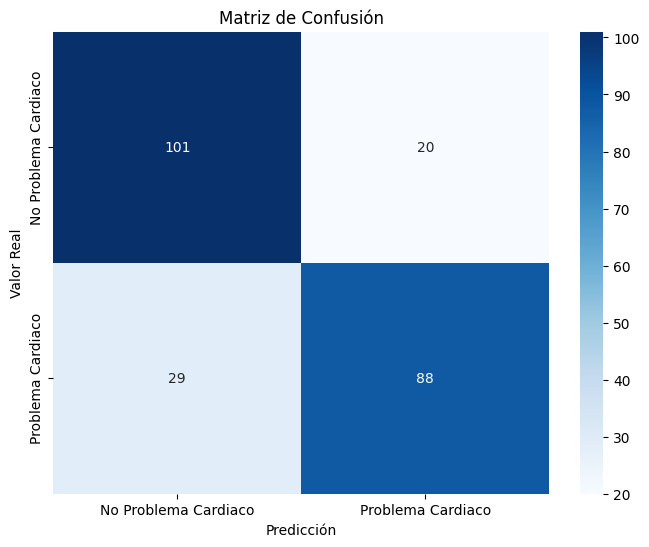

In [ ]:
from sklearn.metrics import confusion_matrix

# Assuming y and y_pred are defined from the previous code block

cm = confusion_matrix(y_train, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Problema Cardiaco', 'Problema Cardiaco'],
            yticklabels=['No Problema Cardiaco', 'Problema Cardiaco'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
# Métricas adicionales
print("\nPrecisión promedio:", metrics.accuracy_score(y_train, y_pred))


Precisión promedio: 0.7941176470588235


## 3. Cross Validation para Series Temporales <a name='6'></a>

In [ ]:

from sklearn.model_selection import TimeSeriesSplit

X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
y = np.array([1, 2, 3, 4, 5, 6])
tscv = TimeSeriesSplit(n_splits=3)

for train, test in tscv.split(X):
    print("Train indices:", train, "Test indices:", test)


Train indices: [0 1 2] Test indices: [3]
Train indices: [0 1 2 3] Test indices: [4]
Train indices: [0 1 2 3 4] Test indices: [5]


## Grid Search con Validación Cruzada <a name='7'></a>


---


### Búsqueda de hiperparámetros con `GridSearchCV`

`GridSearchCV` es una herramienta de `sklearn` que permite **buscar automáticamente la mejor combinación de hiperparámetros** para un modelo, utilizando validación cruzada.



#### ¿Qué hace `GridSearchCV`?
- Recibe un estimador (como `SVC`, `RandomForest`, etc.)
- Un diccionario de hiperparámetros a probar
- Una estrategia de validación cruzada (`cv`)
- Mide el desempeño del modelo para cada combinación
- Devuelve el modelo con los **mejores parámetros encontrados**



### Ejemplo: SVC + GridSearchCV en el dataset de iris



In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# Definimos el modelo base
svc = SVC()

# Definimos el espacio de búsqueda de hiperparámetros
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Configuramos GridSearch con 5 folds
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy')

# Ajustamos la búsqueda
grid_search.fit(X_train, y_train)

# Mostramos los mejores parámetros encontrados
print(" Mejores parámetros encontrados:", grid_search.best_params_)

# Evaluamos el mejor modelo
print(" Mejor precisión media en CV:", grid_search.best_score_)

🔎 Mejores parámetros encontrados: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Mejor precisión media en CV: 0.7979609929078014


## 6. Permutation Test Score <a name='6'></a>
Una prueba de permutación sirve para saber si el desempeño de tu modelo es mejor que el azar. Compara el score real del modelo con scores obtenidos al entrenar modelos con los labels (y_train) aleatoriamente mezclados, manteniendo los features (X_train) iguales.


In [ ]:
from sklearn.model_selection import permutation_test_score

score, perm_scores, pvalue = permutation_test_score(
    clf,               # tu clasificador (modelo)
    X_train,           # datos de entrada
    y_train,           # etiquetas reales
    cv=5,              # validación cruzada de 5 pliegues
    n_permutations=100, # número de permutaciones (cuántas veces mezclar y comparar)
    scoring="accuracy" # métrica de evaluación
)

print(f"Score: {score:.3f}, p-value: {pvalue:.3f}")


Score: 0.794, p-value: 0.010
